# Day 5 – Hourly Demand Forecasting

## Objective

Forecast future Uber Eats order demand using time-series modeling.

In this analysis, order demand will be aggregated at an hourly level and analyzed for trends, seasonality, daily patterns, weekend effects, and peak ordering periods.

### Learning Objectives

- Understand time-series data
- Identify trend, seasonality, and noise
- Perform time-series decomposition
- Test stationarity using the Augmented Dickey-Fuller (ADF) test
- Apply differencing when required
- Build an ARIMA forecasting model
- Build a Prophet forecasting model
- Perform chronological train/test validation
- Compare forecasting models using MAE, RMSE, and MAPE
- Generate a final demand forecast
- Translate forecasting results into business insights

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

print("All Day 5 libraries imported successfully!")

All Day 5 libraries imported successfully!


In [6]:
# Load orders dataset

orders = pd.read_csv("../data/raw/orders.csv")

print("Orders dataset shape:", orders.shape)

display(orders.head())

Orders dataset shape: (50000, 13)


,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,tip_amount,payment_id,order_status,items_count,is_weekend,is_holiday
0,50001,13068,20124,2026-06-17 02:50:21,877.51,87.75,34.48,37.22,70001,Completed,2,False,False
1,50002,13579,20488,2025-09-04 11:42:40,112.57,22.51,98.18,5.62,70002,Completed,1,False,False
2,50003,12934,20451,2026-03-11 07:28:32,1083.58,162.54,88.20,63.72,70003,Completed,4,False,False
3,50004,11504,20078,2026-04-04 18:35:48,197.28,0.00,43.48,3.02,70004,Completed,2,True,False
4,50005,10828,20479,2025-12-17 21:38:43,1579.40,236.91,56.62,153.63,70005,Completed,3,False,False


In [7]:
# Convert order timestamp to datetime

orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

print("Timestamp range:")
print("Start:", orders["order_timestamp"].min())
print("End  :", orders["order_timestamp"].max())

print("\nMissing timestamps:")
print(orders["order_timestamp"].isna().sum())

Timestamp range:
Start: 2025-08-01 00:00:46
End  : 2026-07-31 23:57:32

Missing timestamps:
0


In [8]:
# Aggregate orders into hourly demand

hourly_demand = (
    orders
    .set_index("order_timestamp")
    .resample("h")
    .size()
    .reset_index(name="order_count")
)

print("Hourly demand dataset shape:", hourly_demand.shape)

display(hourly_demand.head(10))

Hourly demand dataset shape: (8760, 2)


,order_timestamp,order_count
0,2025-08-01 00:00:00,8
1,2025-08-01 01:00:00,10
2,2025-08-01 02:00:00,9
3,2025-08-01 03:00:00,6
4,2025-08-01 04:00:00,5
5,2025-08-01 05:00:00,9
6,2025-08-01 06:00:00,5
7,2025-08-01 07:00:00,4
8,2025-08-01 08:00:00,9
9,2025-08-01 09:00:00,6


In [9]:
print("Hourly demand statistics:")
print(hourly_demand["order_count"].describe())

print("\nMissing values:")
print(hourly_demand.isna().sum())

print("\nTime range:")
print(
    hourly_demand["order_timestamp"].min(),
    "to",
    hourly_demand["order_timestamp"].max()
)

Hourly demand statistics:
count    8760.000000
mean        5.707763
std         2.390850
min         0.000000
25%         4.000000
50%         6.000000
75%         7.000000
max        18.000000
Name: order_count, dtype: float64

Missing values:
order_timestamp    0
order_count        0
dtype: int64

Time range:
2025-08-01 00:00:00 to 2026-07-31 23:00:00


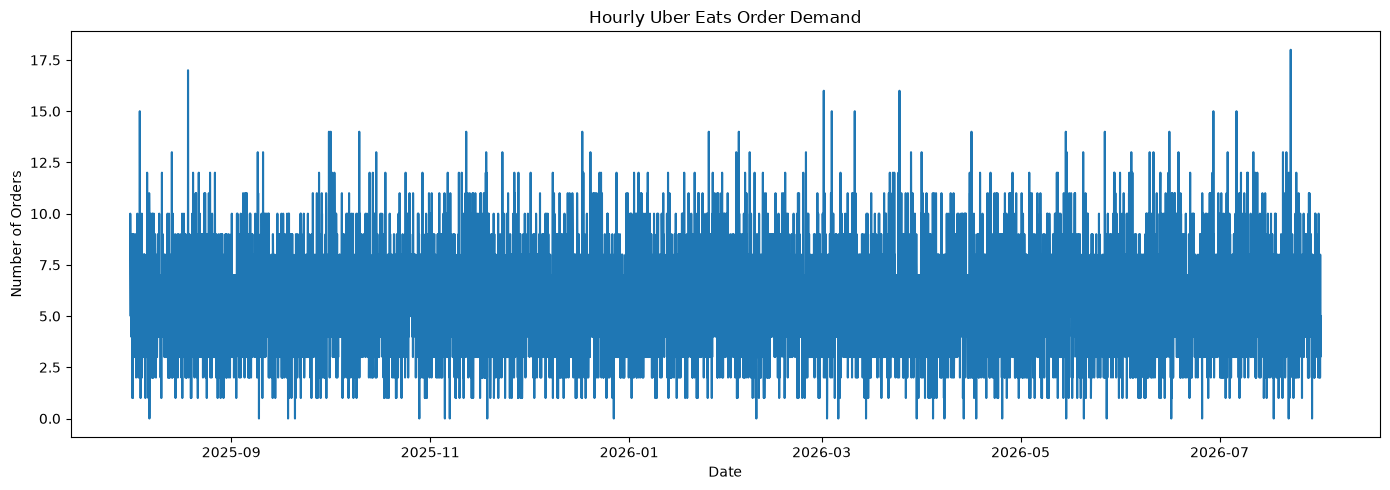

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    hourly_demand["order_timestamp"],
    hourly_demand["order_count"]
)

plt.title("Hourly Uber Eats Order Demand")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

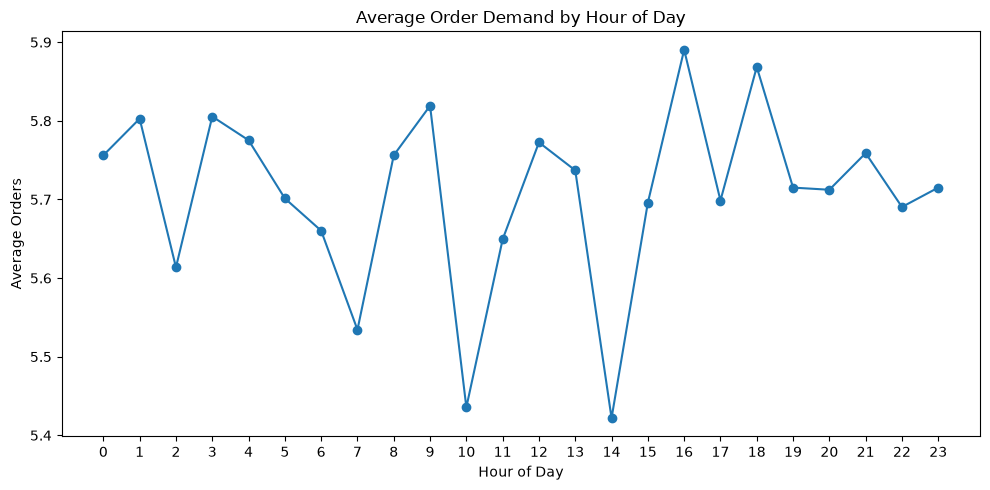

In [11]:
hourly_demand["hour"] = (
    hourly_demand["order_timestamp"].dt.hour
)

hourly_pattern = (
    hourly_demand
    .groupby("hour")["order_count"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Order Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Orders")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

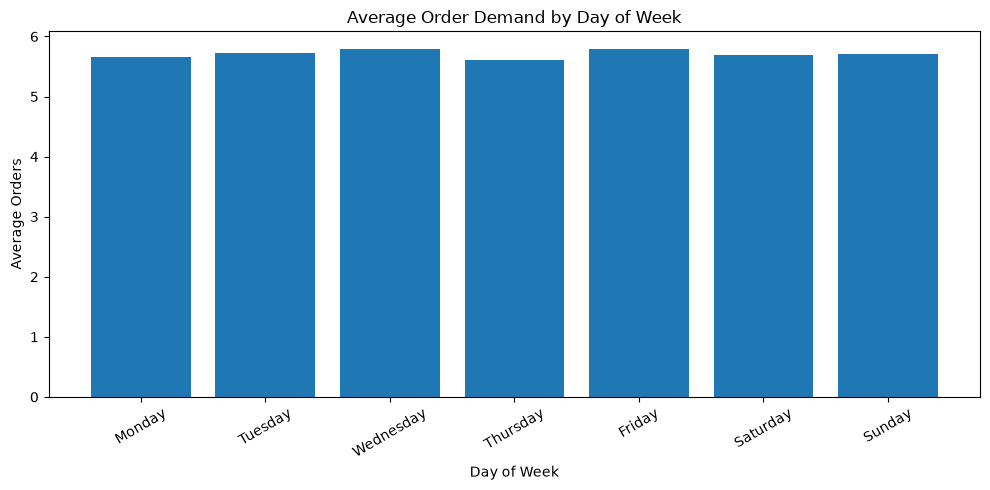

In [12]:
hourly_demand["day_of_week"] = (
    hourly_demand["order_timestamp"].dt.dayofweek
)

day_pattern = (
    hourly_demand
    .groupby("day_of_week")["order_count"]
    .mean()
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.bar(
    day_names,
    day_pattern.values
)

plt.title("Average Order Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [14]:
hourly_demand["is_weekend"] = (
    hourly_demand["day_of_week"] >= 5
)

weekend_pattern = (
    hourly_demand
    .groupby("is_weekend")["order_count"]
    .mean()
)

print("Average hourly demand:")
print(
    "Weekday:",
    round(weekend_pattern[False], 2)
)

print(
    "Weekend:",
    round(weekend_pattern[True], 2)
)

Average hourly demand:
Weekday: 5.71
Weekend: 5.7


In [15]:
peak_hours = (
    hourly_pattern
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 peak ordering hours:")
print(peak_hours)

Top 5 peak ordering hours:
hour
16    5.890411
18    5.868493
9     5.819178
3     5.805479
1     5.802740
Name: order_count, dtype: float64


In [16]:
# Prepare hourly time series

ts = (
    hourly_demand
    .set_index("order_timestamp")["order_count"]
    .asfreq("h")
)

print("Time series length:", len(ts))
print("Frequency:", ts.index.freq)
print("Missing values:", ts.isna().sum())

Time series length: 8760
Frequency: <Hour>
Missing values: 0


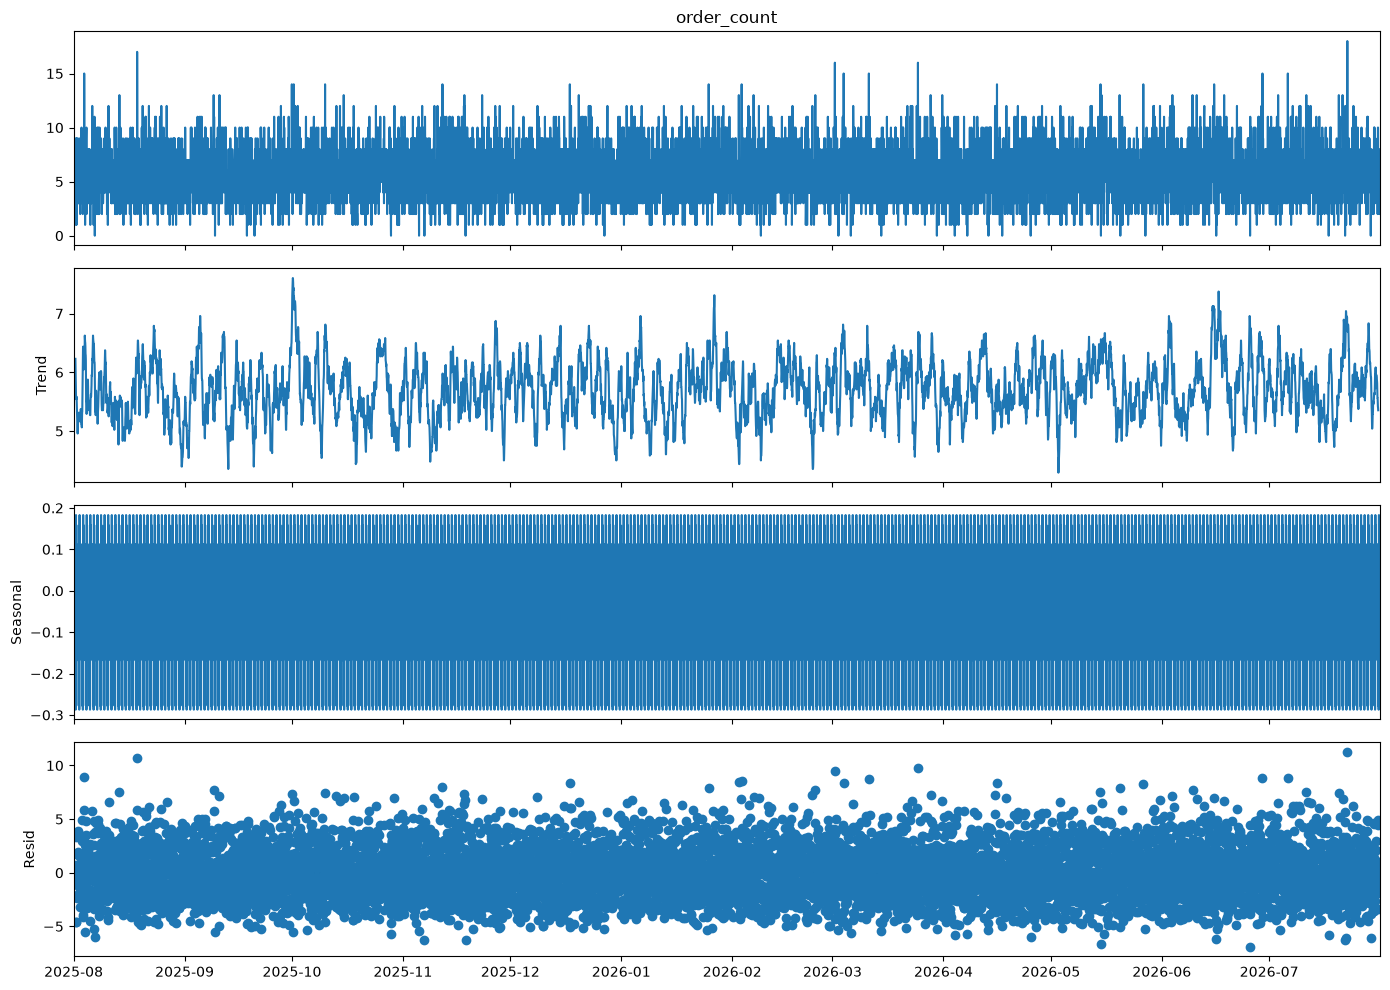

In [17]:
# Decompose hourly demand using a 24-hour seasonal period

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

In [18]:
# Display summary statistics of decomposition components

decomposition_summary = pd.DataFrame({
    "Trend": decomposition.trend,
    "Seasonality": decomposition.seasonal,
    "Residual": decomposition.resid
})

display(
    decomposition_summary.describe()
)

,Trend,Seasonality,Residual
count,8736.000000,8.760000e+03,8736.000000
mean,5.706876,5.399030e-18,-0.000260
std,0.477304,1.134492e-01,2.340663
min,4.291667,-2.871714e-01,-6.891228
25%,5.375000,-2.141760e-02,-1.682895
50%,5.708333,1.333801e-02,-0.148325
75%,6.041667,6.346106e-02,1.495333
max,7.604167,1.828950e-01,11.254605


In [19]:
# Augmented Dickey-Fuller test

adf_result = adfuller(ts)

print("Augmented Dickey-Fuller Test")
print("=" * 35)

print(f"ADF Statistic : {adf_result[0]:.6f}")
print(f"p-value       : {adf_result[1]:.6f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.6f}")

Augmented Dickey-Fuller Test
ADF Statistic : -94.212511
p-value       : 0.000000
Lags Used     : 0
Observations  : 8759

Critical Values:
1%: -3.431097
5%: -2.861870
10%: -2.566946


In [20]:
# Interpret ADF test

p_value = adf_result[1]

if p_value < 0.05:
    print("Result: The series is stationary (reject H0).")
else:
    print("Result: The series is non-stationary (fail to reject H0).")

Result: The series is stationary (reject H0).


In [21]:
# Chronological train/test split

split_index = int(len(ts) * 0.80)

train_ts = ts.iloc[:split_index]
test_ts = ts.iloc[split_index:]

print("Training observations:", len(train_ts))
print("Testing observations :", len(test_ts))

print("\nTraining period:")
print(train_ts.index.min(), "to", train_ts.index.max())

print("\nTesting period:")
print(test_ts.index.min(), "to", test_ts.index.max())

Training observations: 7008
Testing observations : 1752

Training period:
2025-08-01 00:00:00 to 2026-05-19 23:00:00

Testing period:
2026-05-20 00:00:00 to 2026-07-31 23:00:00


In [22]:
# ARIMA model

arima_model = ARIMA(
    train_ts,
    order=(1, 0, 1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:            order_count   No. Observations:                 7008
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -16021.154
Date:                Tue, 18 Aug 2026   AIC                          32050.308
Time:                        17:38:42   BIC                          32077.727
Sample:                    08-01-2025   HQIC                         32059.756
                         - 05-19-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6945      0.029    195.217      0.000       5.637       5.752
ar.L1          0.2940      1.502      0.196      0.845      -2.649       3.237
ma.L1         -0.3010      1.499     -0.201      0.8

In [23]:
# Forecast the test period

arima_forecast = arima_result.forecast(
    steps=len(test_ts)
)

arima_forecast.index = test_ts.index

print("ARIMA forecast generated successfully!")

display(
    arima_forecast.head(10)
)

ARIMA forecast generated successfully!


order_timestamp
2026-05-20 00:00:00    5.682750
2026-05-20 01:00:00    5.691033
2026-05-20 02:00:00    5.693468
2026-05-20 03:00:00    5.694185
2026-05-20 04:00:00    5.694395
2026-05-20 05:00:00    5.694457
2026-05-20 06:00:00    5.694475
2026-05-20 07:00:00    5.694481
2026-05-20 08:00:00    5.694482
2026-05-20 09:00:00    5.694483
Freq: h, Name: predicted_mean, dtype: float64

In [24]:
# ARIMA evaluation metrics

arima_mae = mean_absolute_error(
    test_ts,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        arima_forecast
    )
)

# MAPE calculated only where actual demand is non-zero
non_zero_mask = test_ts != 0

arima_mape = (
    np.mean(
        np.abs(
            (test_ts[non_zero_mask] - arima_forecast[non_zero_mask])
            / test_ts[non_zero_mask]
        )
    ) * 100
)

print("ARIMA Performance")
print("=" * 35)
print(f"MAE  : {arima_mae:.4f}")
print(f"RMSE : {arima_rmse:.4f}")
print(f"MAPE : {arima_mape:.2f}%")

ARIMA Performance
MAE  : 1.9272
RMSE : 2.4322
MAPE : 46.92%


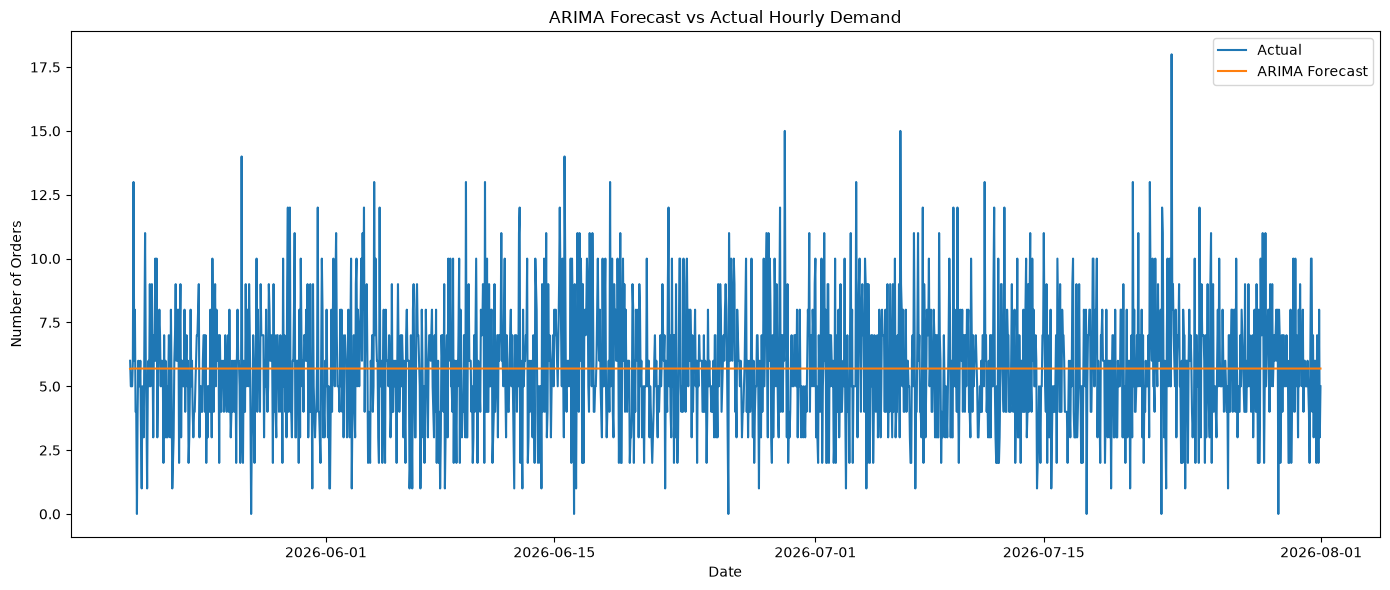

In [25]:
# Plot ARIMA forecast against actual demand

plt.figure(figsize=(14, 6))

plt.plot(
    test_ts.index,
    test_ts.values,
    label="Actual"
)

plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Hourly Demand")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

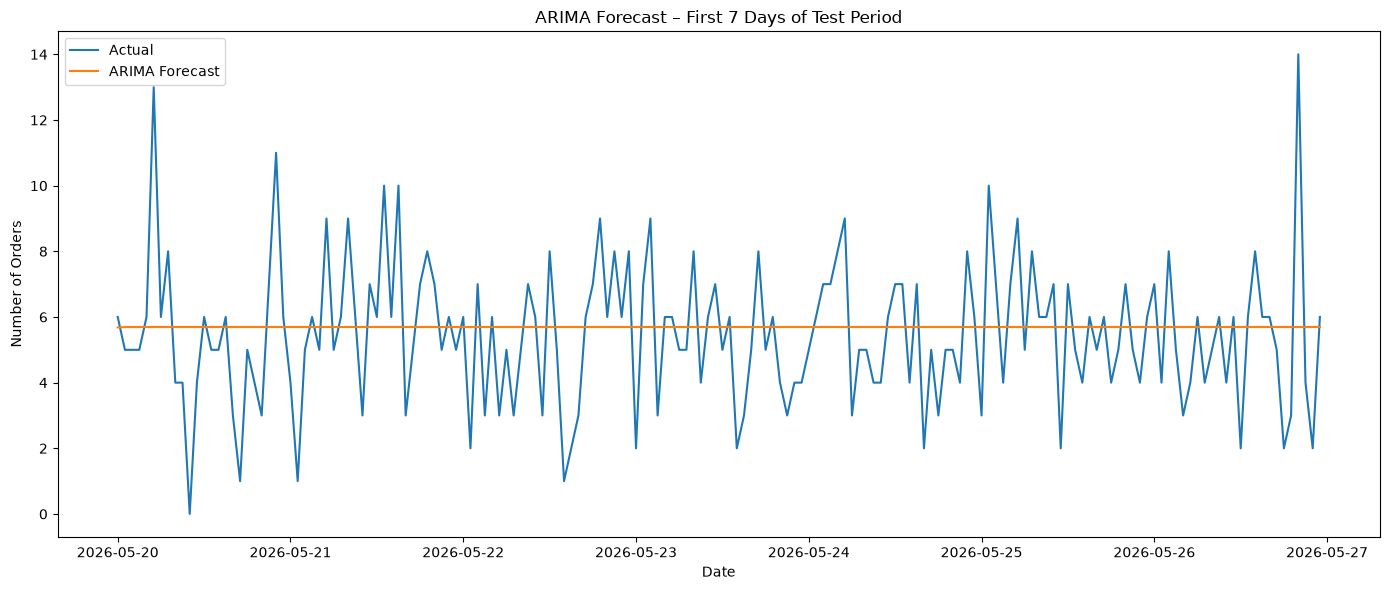

In [26]:
# First 7 days of ARIMA forecast

forecast_days = 24 * 7

plt.figure(figsize=(14, 6))

plt.plot(
    test_ts.index[:forecast_days],
    test_ts.values[:forecast_days],
    label="Actual"
)

plt.plot(
    arima_forecast.index[:forecast_days],
    arima_forecast.values[:forecast_days],
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast – First 7 Days of Test Period")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Prepare data for Prophet

prophet_data = hourly_demand[
    ["order_timestamp", "order_count"]
].copy()

prophet_data = prophet_data.rename(
    columns={
        "order_timestamp": "ds",
        "order_count": "y"
    }
)

print("Prophet dataset shape:", prophet_data.shape)

display(prophet_data.head())

Prophet dataset shape: (8760, 2)


,ds,y
0,2025-08-01 00:00:00,8
1,2025-08-01 01:00:00,10
2,2025-08-01 02:00:00,9
3,2025-08-01 03:00:00,6
4,2025-08-01 04:00:00,5


In [28]:
# Chronological train/test split for Prophet

prophet_train = prophet_data.iloc[:split_index].copy()
prophet_test = prophet_data.iloc[split_index:].copy()

print("Prophet training observations:", len(prophet_train))
print("Prophet testing observations :", len(prophet_test))

print("\nTraining period:")
print(prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("\nTesting period:")
print(prophet_test["ds"].min(), "to", prophet_test["ds"].max())

Prophet training observations: 7008
Prophet testing observations : 1752

Training period:
2025-08-01 00:00:00 to 2026-05-19 23:00:00

Testing period:
2026-05-20 00:00:00 to 2026-07-31 23:00:00


In [29]:
# Build Prophet forecasting model

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully!")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
17:45:44 - cmdstanpy - INFO - Chain [1] start processing
17:45:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [30]:
# Generate Prophet forecast

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="h"
)

prophet_forecast_full = prophet_model.predict(
    future
)

print("Prophet forecast generated successfully!")

display(
    prophet_forecast_full[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail()
)

Prophet forecast generated successfully!


,ds,yhat,yhat_lower,yhat_upper
8755,2026-07-31 19:00:00,4.212811,1.343920,7.480338
8756,2026-07-31 20:00:00,4.165304,1.141364,7.300969
8757,2026-07-31 21:00:00,4.150778,1.300992,7.261949
8758,2026-07-31 22:00:00,4.159074,1.038607,7.142806
8759,2026-07-31 23:00:00,4.168102,1.138831,7.354478


In [31]:
# Extract Prophet predictions for the test period

prophet_forecast = prophet_forecast_full[
    prophet_forecast_full["ds"].isin(
        prophet_test["ds"]
    )
].copy()

print("Prophet test predictions:", len(prophet_forecast))

Prophet test predictions: 1752


In [32]:
# Prophet model with supported seasonality

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

print("Final Prophet model trained successfully!")

17:49:52 - cmdstanpy - INFO - Chain [1] start processing
17:49:53 - cmdstanpy - INFO - Chain [1] done processing


Final Prophet model trained successfully!


In [33]:
# Generate forecast for the test period

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="h"
)

prophet_forecast_full = prophet_model.predict(
    future
)

prophet_forecast = prophet_forecast_full[
    prophet_forecast_full["ds"].isin(
        prophet_test["ds"]
    )
].copy()

print(
    "Prophet test predictions:",
    len(prophet_forecast)
)

Prophet test predictions: 1752


In [34]:
# Prophet evaluation

prophet_actual = prophet_test["y"].values
prophet_predicted = prophet_forecast["yhat"].values

prophet_mae = mean_absolute_error(
    prophet_actual,
    prophet_predicted
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_actual,
        prophet_predicted
    )
)

# MAPE excluding zero actual values
non_zero_mask = prophet_actual != 0

prophet_mape = (
    np.mean(
        np.abs(
            (
                prophet_actual[non_zero_mask]
                - prophet_predicted[non_zero_mask]
            )
            / prophet_actual[non_zero_mask]
        )
    ) * 100
)

print("Prophet Performance")
print("=" * 35)
print(f"MAE  : {prophet_mae:.4f}")
print(f"RMSE : {prophet_rmse:.4f}")
print(f"MAPE : {prophet_mape:.2f}%")

Prophet Performance
MAE  : 1.9223
RMSE : 2.4333
MAPE : 47.58%


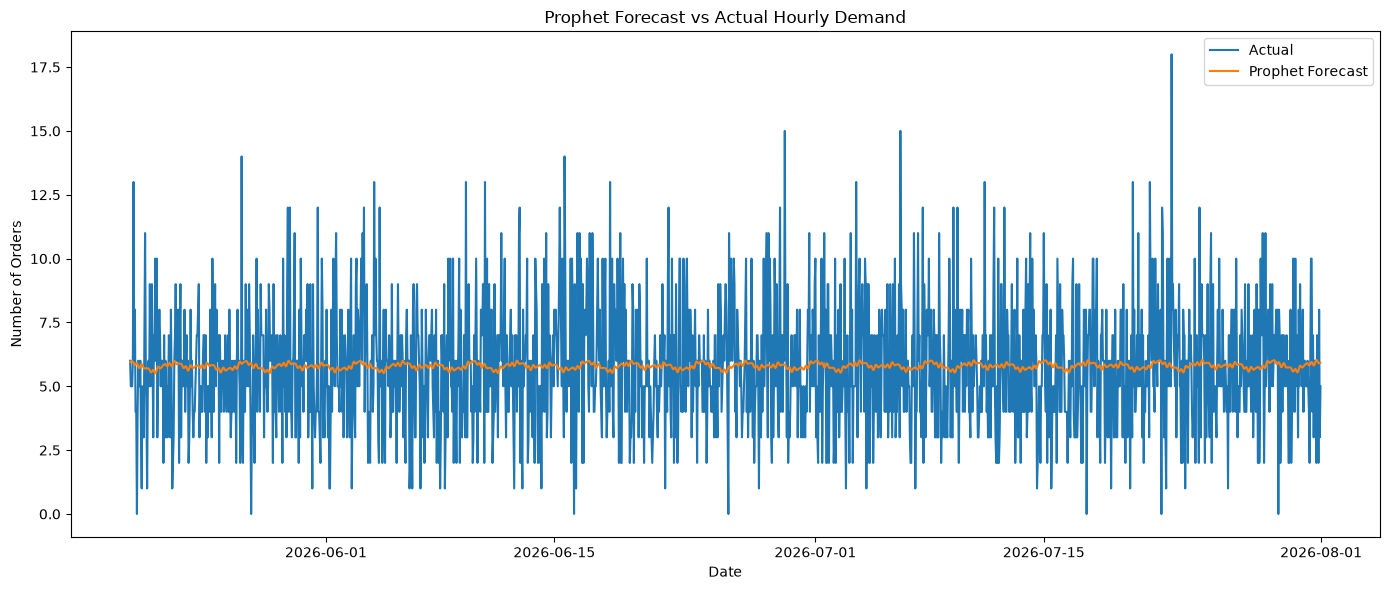

In [35]:
# Prophet forecast vs actual demand

plt.figure(figsize=(14, 6))

plt.plot(
    prophet_test["ds"],
    prophet_actual,
    label="Actual"
)

plt.plot(
    prophet_test["ds"],
    prophet_predicted,
    label="Prophet Forecast"
)

plt.title("Prophet Forecast vs Actual Hourly Demand")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

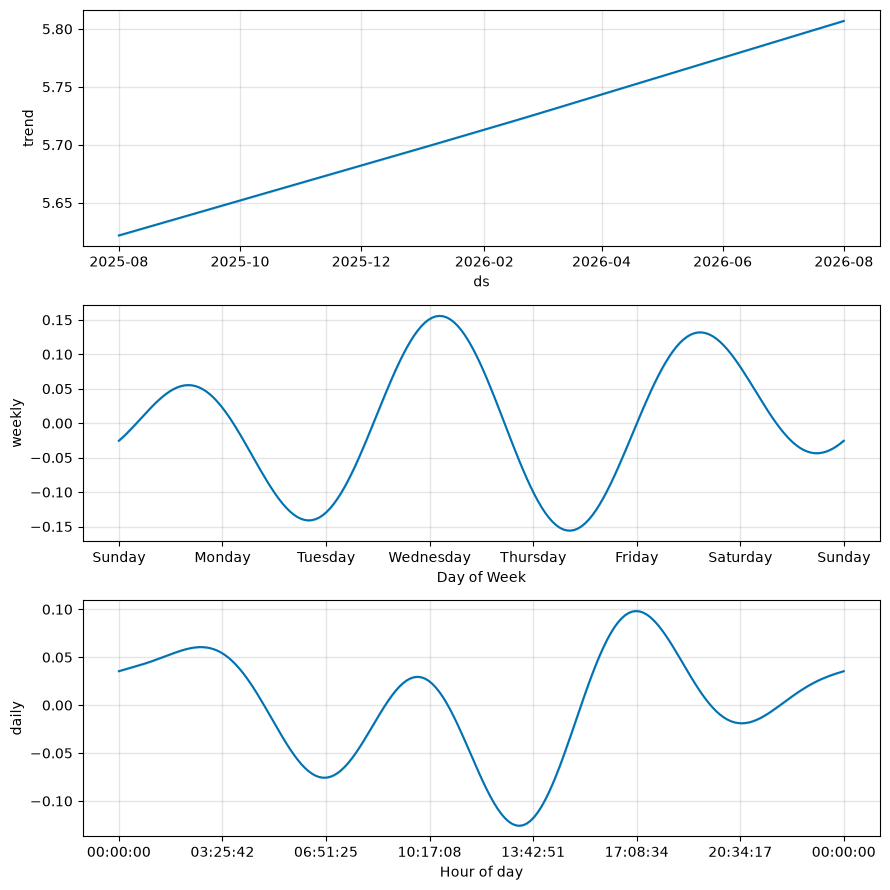

In [36]:
# Prophet components

fig = prophet_model.plot_components(
    prophet_forecast_full
)

plt.tight_layout()
plt.show()

In [37]:
# Compare ARIMA and Prophet

forecast_comparison = pd.DataFrame({
    "Model": [
        "ARIMA",
        "Prophet"
    ],
    "MAE": [
        arima_mae,
        prophet_mae
    ],
    "RMSE": [
        arima_rmse,
        prophet_rmse
    ],
    "MAPE": [
        arima_mape,
        prophet_mape
    ]
})

display(
    forecast_comparison.sort_values("MAE")
)

,Model,MAE,RMSE,MAPE
1,Prophet,1.922297,2.433312,47.581432
0,ARIMA,1.927197,2.432245,46.923672


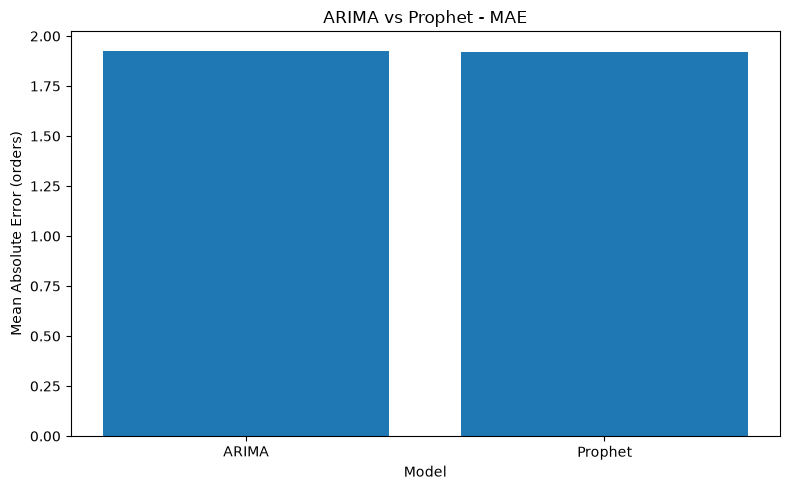

In [38]:
# Compare forecasting models using MAE

plt.figure(figsize=(8, 5))

plt.bar(
    forecast_comparison["Model"],
    forecast_comparison["MAE"]
)

plt.title("ARIMA vs Prophet - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (orders)")

plt.tight_layout()
plt.show()

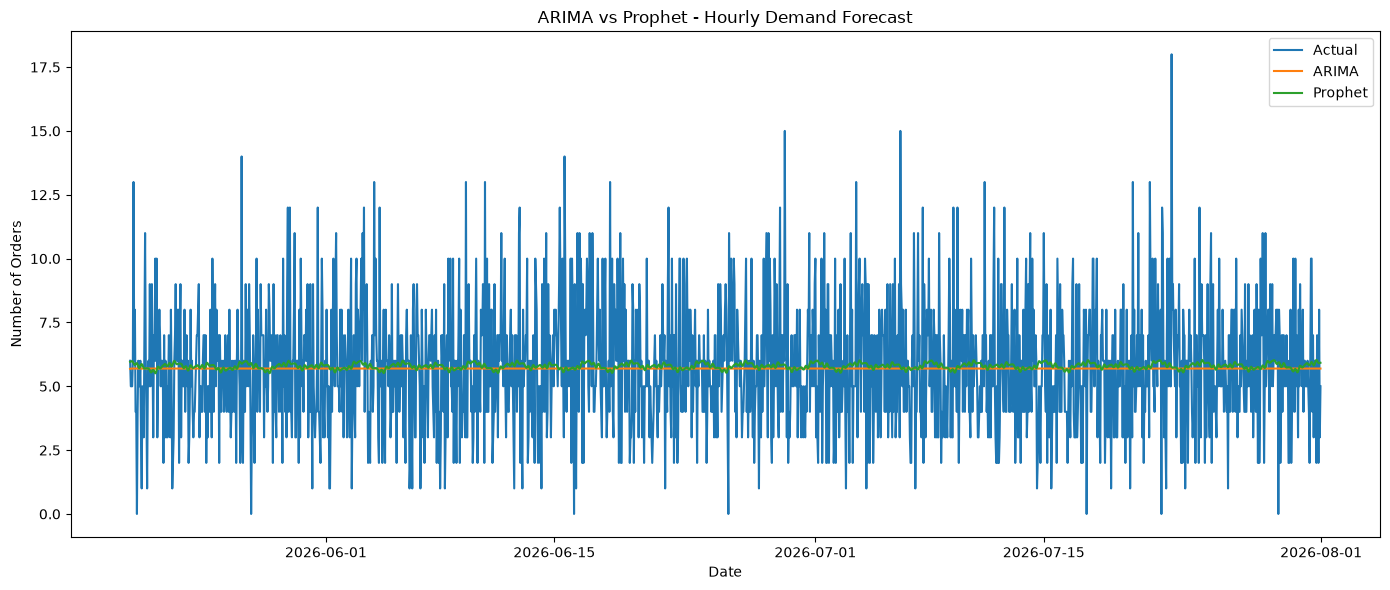

In [40]:
# Compare ARIMA and Prophet forecasts

plt.figure(figsize=(14, 6))

plt.plot(
    test_ts.index,
    test_ts.values,
    label="Actual"
)

plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA"
)

plt.plot(
    prophet_forecast["ds"],
    prophet_forecast["yhat"],
    label="Prophet"
)

plt.title("ARIMA vs Prophet - Hourly Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Select best forecasting model based on MAE

best_forecast_model = forecast_comparison.loc[
    forecast_comparison["MAE"].idxmin()
]

print("Best Forecasting Model")
print("=" * 35)
print(f"Model : {best_forecast_model['Model']}")
print(f"MAE   : {best_forecast_model['MAE']:.4f}")
print(f"RMSE  : {best_forecast_model['RMSE']:.4f}")
print(f"MAPE  : {best_forecast_model['MAPE']:.2f}%")

Best Forecasting Model
Model : Prophet
MAE   : 1.9223
RMSE  : 2.4333
MAPE  : 47.58%


##Prophet achieved the lowest MAE, while ARIMA achieved a marginally lower RMSE. Overall, both models performed very similarly, with Prophet selected as the final model based on the primary MAE criterion.

Also, the MAPE values around 47% should be interpreted cautiously because the demand series contains zero and low-volume hours. MAE and RMSE are more reliable here.

In [43]:
# Train final Prophet model using all available historical data

final_prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

final_prophet_model.fit(
    prophet_data
)

print("Final Prophet model trained on all historical data!")

17:59:15 - cmdstanpy - INFO - Chain [1] start processing
17:59:16 - cmdstanpy - INFO - Chain [1] done processing


Final Prophet model trained on all historical data!


In [44]:
# Forecast the next 7 days

future_7_days = final_prophet_model.make_future_dataframe(
    periods=24 * 7,
    freq="h"
)

final_forecast = final_prophet_model.predict(
    future_7_days
)

future_demand = final_forecast[
    final_forecast["ds"] > prophet_data["ds"].max()
].copy()

print("Future forecast observations:", len(future_demand))

display(
    future_demand[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].head(24)
)

Future forecast observations: 168


,ds,yhat,yhat_lower,yhat_upper
8760,2026-08-01 00:00:00,5.865879,2.735939,8.855825
8761,2026-08-01 01:00:00,5.857208,2.710169,8.719812
8762,2026-08-01 02:00:00,5.845116,2.753047,8.974902
8763,2026-08-01 03:00:00,5.832649,2.885658,9.120201
8764,2026-08-01 04:00:00,5.813418,2.915659,9.038552
8765,2026-08-01 05:00:00,5.779706,2.612533,8.951002
8766,2026-08-01 06:00:00,5.735409,2.789901,8.805703
8767,2026-08-01 07:00:00,5.697767,2.738007,8.766359
8768,2026-08-01 08:00:00,5.683188,2.609986,8.777072
8769,2026-08-01 09:00:00,5.690295,2.692595,8.837761


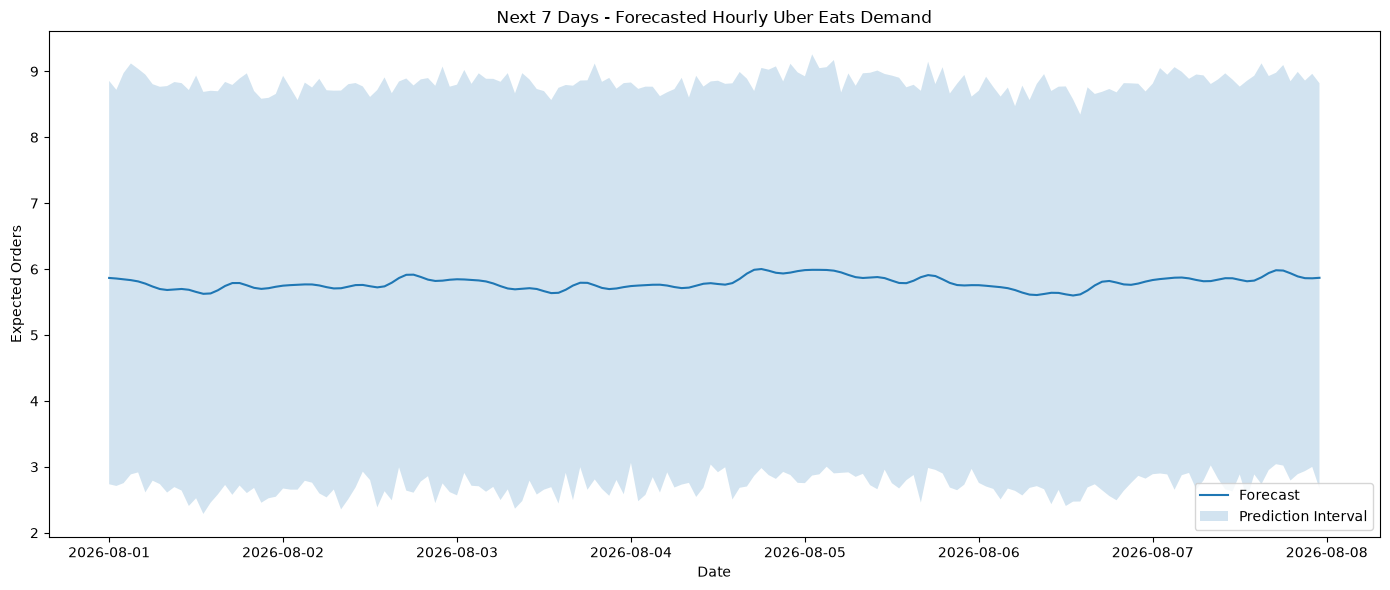

In [45]:
# Plot next 7 days of forecast

plt.figure(figsize=(14, 6))

plt.plot(
    future_demand["ds"],
    future_demand["yhat"],
    label="Forecast"
)

plt.fill_between(
    future_demand["ds"],
    future_demand["yhat_lower"],
    future_demand["yhat_upper"],
    alpha=0.2,
    label="Prediction Interval"
)

plt.title("Next 7 Days - Forecasted Hourly Uber Eats Demand")
plt.xlabel("Date")
plt.ylabel("Expected Orders")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# Identify highest forecasted demand hours

top_forecast_hours = (
    future_demand[
        ["ds", "yhat"]
    ]
    .sort_values(
        "yhat",
        ascending=False
    )
    .head(10)
)

print("Top 10 forecasted demand hours:")
display(top_forecast_hours)

Top 10 forecasted demand hours:


,ds,yhat
8850,2026-08-04 18:00:00,6.001165
8849,2026-08-04 17:00:00,5.989667
8857,2026-08-05 01:00:00,5.989003
8858,2026-08-05 02:00:00,5.988702
8859,2026-08-05 03:00:00,5.986688
8856,2026-08-05 00:00:00,5.984700
8921,2026-08-07 17:00:00,5.982521
8922,2026-08-07 18:00:00,5.978014
8860,2026-08-05 04:00:00,5.976436
8851,2026-08-04 19:00:00,5.975787


In [47]:
# Forecast summary

print("7-Day Demand Forecast Summary")
print("=" * 40)

print(
    f"Average forecasted hourly demand: "
    f"{future_demand['yhat'].mean():.2f} orders"
)

print(
    f"Maximum forecasted hourly demand: "
    f"{future_demand['yhat'].max():.2f} orders"
)

print(
    f"Minimum forecasted hourly demand: "
    f"{future_demand['yhat'].min():.2f} orders"
)

print(
    f"Total forecasted orders over 7 days: "
    f"{future_demand['yhat'].sum():.0f}"
)

7-Day Demand Forecast Summary
Average forecasted hourly demand: 5.79 orders
Maximum forecasted hourly demand: 6.00 orders
Minimum forecasted hourly demand: 5.60 orders
Total forecasted orders over 7 days: 973


## Business Interpretation

The demand forecasting analysis provides several insights for Uber Eats operational planning.

### 1. Demand is relatively stable

Historical hourly demand averaged approximately **5.71 orders per hour**, with a maximum observed hourly demand of 18 orders.

The final Prophet forecast predicts an average of approximately **5.79 orders per hour** for the next seven days.

This indicates that the model expects demand to remain relatively stable rather than experience a major increase or decrease.

### 2. Limited weekend effect

The historical analysis showed almost identical average hourly demand for weekdays and weekends:

- Weekday: **5.71 orders/hour**
- Weekend: **5.70 orders/hour**

Therefore, this dataset does not provide evidence of a meaningful weekend demand increase.

### 3. Peak ordering periods

Historical analysis identified the following top demand hours:

- 16:00
- 18:00
- 09:00
- 03:00
- 01:00

The differences between these periods were relatively small, indicating that demand does not have a very strong peak-hour pattern in this dataset.

### 4. Forecasted demand

The final Prophet model forecasts approximately **973 orders over the next seven days**.

Expected hourly demand ranges from approximately **5.60 to 6.00 orders**.

This relatively narrow range indicates a stable short-term demand outlook.

### 5. Operational planning

The forecast can support:

- Driver allocation
- Restaurant staffing
- Delivery capacity planning
- Short-term resource allocation
- Anticipating periods of relatively higher demand

Because the predicted demand is relatively stable, major capacity changes are not indicated by this forecast alone.

### Overall Conclusion

The time-series analysis shows that hourly Uber Eats demand in this dataset is largely stationary and relatively stable.

The ADF test confirmed stationarity, so differencing was not required before ARIMA modeling.

Both ARIMA and Prophet produced similar forecasting performance. Prophet achieved the lowest MAE, while ARIMA achieved a marginally lower RMSE.

Prophet was selected as the final forecasting model based on the primary MAE criterion.

The final seven-day forecast estimates approximately **973 orders**, with average hourly demand of approximately **5.79 orders**.

In [48]:
# Save hourly demand dataset

hourly_demand.to_csv(
    "../data/processed/hourly_demand.csv",
    index=False
)

print("Hourly demand dataset saved successfully.")

Hourly demand dataset saved successfully.


In [49]:
# Save final 7-day demand forecast

final_forecast_output = future_demand[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

final_forecast_output = final_forecast_output.rename(
    columns={
        "ds": "forecast_timestamp",
        "yhat": "predicted_orders",
        "yhat_lower": "lower_bound",
        "yhat_upper": "upper_bound"
    }
)

final_forecast_output.to_csv(
    "../data/processed/demand_forecast_7_days.csv",
    index=False
)

print("Final 7-day demand forecast saved successfully.")

display(final_forecast_output.head())

Final 7-day demand forecast saved successfully.


,forecast_timestamp,predicted_orders,lower_bound,upper_bound
8760,2026-08-01 00:00:00,5.865879,2.735939,8.855825
8761,2026-08-01 01:00:00,5.857208,2.710169,8.719812
8762,2026-08-01 02:00:00,5.845116,2.753047,8.974902
8763,2026-08-01 03:00:00,5.832649,2.885658,9.120201
8764,2026-08-01 04:00:00,5.813418,2.915659,9.038552
